In [1]:
# Day 4. 지도학습 - 회귀 실습
# 실제 업로드 파일 기준: supervised_label_cn7.csv
# 회귀 타깃: Filling_Time

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

In [3]:
plt.rcParams["figure.figsize"] = (8, 5)
pd.set_option("display.max_columns", 100)
np.random.seed(42)

In [4]:
file_path = "supervised_label_cn7.csv"
df = pd.read_csv(file_path)
display(df)

,Unnamed: 0,PassOrFail,Injection_Time,Filling_Time,Plasticizing_Time,Cycle_Time,Clamp_Close_Time,Cushion_Position,Plasticizing_Position,Clamp_Open_Position,Max_Injection_Speed,Max_Screw_RPM,Average_Screw_RPM,Max_Injection_Pressure,Max_Switch_Over_Pressure,Max_Back_Pressure,Average_Back_Pressure,Barrel_Temperature_1,Barrel_Temperature_2,Barrel_Temperature_3,Barrel_Temperature_4,Barrel_Temperature_5,Barrel_Temperature_6,Hopper_Temperature,Mold_Temperature_3,Mold_Temperature_4
0,0,0,9.60,4.48,16.910000,59.580002,7.13,653.409973,68.839996,647.98999,55.299999,30.799999,292.500000,141.800003,136.899994,37.500000,59.299999,276.200012,275.500000,275.299988,270.799988,254.699997,229.500000,67.199997,24.799999,27.600000
1,1,0,9.59,4.48,16.910000,59.560001,7.13,653.419983,68.839996,647.98999,55.299999,31.000000,292.500000,141.800003,136.800003,37.500000,59.299999,276.500000,275.000000,275.399994,271.100006,254.899994,230.000000,66.900002,25.000000,27.600000
2,2,0,9.58,4.46,16.900000,59.580002,7.13,653.409973,68.839996,647.98999,55.599998,30.900000,292.500000,141.699997,136.399994,37.700001,59.400002,276.299988,275.299988,275.200012,271.399994,255.000000,230.000000,67.500000,25.000000,27.600000
3,3,0,9.58,4.46,16.920000,59.560001,7.13,653.409973,68.849998,647.98999,55.500000,30.600000,292.399994,141.800003,136.699997,37.400002,59.299999,275.799988,275.399994,275.000000,271.299988,255.000000,230.000000,67.000000,25.000000,27.600000
4,4,0,9.57,4.45,16.910000,59.520000,7.14,653.409973,68.830002,647.98999,55.700001,30.799999,292.500000,141.600006,136.399994,37.099998,59.099998,275.700012,274.899994,274.799988,270.799988,255.399994,230.100006,66.699997,24.799999,27.500000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6731,6731,0,9.58,4.46,16.670000,59.520000,7.11,653.429993,68.339996,647.98999,55.200001,30.600000,29.200001,142.199997,136.399994,37.900002,59.700001,275.799988,275.500000,275.500000,269.500000,255.000000,230.199997,66.000000,21.000000,22.400000
6732,6732,0,9.60,4.49,16.650000,59.540001,7.11,653.429993,68.320000,647.98999,54.900002,30.799999,29.200001,142.100006,136.899994,38.099998,59.799999,276.100006,275.899994,274.899994,269.700012,254.600006,229.600006,65.400002,21.000000,22.400000
6733,6733,0,9.60,4.48,16.620001,59.560001,7.11,653.429993,68.330002,647.98999,54.900002,30.700001,29.200001,142.100006,137.000000,38.299999,59.900002,276.500000,274.899994,275.100006,269.500000,255.600006,229.600006,66.099998,21.000000,22.400000
6734,6734,0,9.60,4.48,16.650000,59.560001,7.11,653.429993,68.349998,647.98999,55.000000,30.700001,29.200001,142.100006,136.800003,38.400002,59.900002,275.799988,275.299988,275.500000,270.700012,254.899994,230.000000,66.099998,21.000000,22.400000


In [5]:
df = df.drop(columns=["Unnamed: 0"])
display(df.shape)

(6736, 25)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6736 entries, 0 to 6735
Data columns (total 25 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   PassOrFail                6736 non-null   int64  
 1   Injection_Time            6736 non-null   float64
 2   Filling_Time              6736 non-null   float64
 3   Plasticizing_Time         6736 non-null   float64
 4   Cycle_Time                6736 non-null   float64
 5   Clamp_Close_Time          6736 non-null   float64
 6   Cushion_Position          6736 non-null   float64
 7   Plasticizing_Position     6736 non-null   float64
 8   Clamp_Open_Position       6736 non-null   float64
 9   Max_Injection_Speed       6736 non-null   float64
 10  Max_Screw_RPM             6736 non-null   float64
 11  Average_Screw_RPM         6736 non-null   float64
 12  Max_Injection_Pressure    6736 non-null   float64
 13  Max_Switch_Over_Pressure  6736 non-null   float64
 14  Max_Back

In [7]:
display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
PassOrFail,6736.0,0.005790,0.075876,0.000000,0.000000,0.000000,0.000000,1.000000
Injection_Time,6736.0,9.580064,0.180526,9.360000,9.530000,9.570000,9.600000,13.390000
Filling_Time,6736.0,4.448425,0.140286,3.350000,4.420000,4.450000,4.480000,8.270000
Plasticizing_Time,6736.0,16.820433,0.288946,16.469999,16.629999,16.820000,16.910000,21.100000
Cycle_Time,6736.0,59.549314,0.372267,58.840000,59.480000,59.520000,59.540001,64.349998
Clamp_Close_Time,6736.0,7.113639,0.075843,6.070000,7.120000,7.120000,7.120000,7.180000
Cushion_Position,6736.0,653.440859,0.115004,653.390015,653.429993,653.429993,653.440002,655.000000
Plasticizing_Position,6736.0,68.381941,0.648307,59.759998,68.320000,68.360001,68.510002,68.860001
Clamp_Open_Position,6736.0,644.899046,42.170577,69.639999,647.989990,647.989990,647.989990,647.989990
Max_Injection_Speed,6736.0,55.523085,1.005340,38.500000,55.099998,55.400002,55.900002,64.800003


In [8]:
target_col = "Filling_Time"

In [9]:
# 데이터(X) / 정답(y) 분리
#    - target 자체는 X에서 제거
#    - PassOrFail은 결과 라벨이므로 회귀 입력에서 제외
drop_cols = [target_col, "PassOrFail"]
X = df.drop(columns=drop_cols)
y = df[target_col]

print("\n=== X, y 크기 ===")
print("X shape:", X.shape)
print("y shape:", y.shape)


=== X, y 크기 ===
X shape: (6736, 23)
y shape: (6736,)


In [10]:
print(X.columns.tolist())

['Injection_Time', 'Plasticizing_Time', 'Cycle_Time', 'Clamp_Close_Time', 'Cushion_Position', 'Plasticizing_Position', 'Clamp_Open_Position', 'Max_Injection_Speed', 'Max_Screw_RPM', 'Average_Screw_RPM', 'Max_Injection_Pressure', 'Max_Switch_Over_Pressure', 'Max_Back_Pressure', 'Average_Back_Pressure', 'Barrel_Temperature_1', 'Barrel_Temperature_2', 'Barrel_Temperature_3', 'Barrel_Temperature_4', 'Barrel_Temperature_5', 'Barrel_Temperature_6', 'Hopper_Temperature', 'Mold_Temperature_3', 'Mold_Temperature_4']


In [11]:
display(y.describe())

count    6736.000000
mean        4.448425
std         0.140286
min         3.350000
25%         4.420000
50%         4.450000
75%         4.480000
max         8.270000
Name: Filling_Time, dtype: float64

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("\n=== train / test 크기 ===")
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)


=== train / test 크기 ===
X_train: (5388, 23)
X_test : (1348, 23)
y_train: (5388,)
y_test : (1348,)


In [13]:
# 회귀 평가 함수
def reg_metrics(y_true, y_pred, model, model_name="Model"):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    r2 = r2_score(y_true, y_pred)

    # print(f"\n=== {model_name} 성능 ===")
    # print("MAE :", round(mae, 4))
    # print("RMSE:", round(rmse, 4))
    # print("R²  :", round(r2, 4))

    return {
        "mae": mae,
        "rmse": rmse,
        "r2": r2,
        "model": model,
        "model_name": model_name
    }

In [14]:
# 상관이 큰 변수 확인
corr_with_target = df.corr(numeric_only=True)[target_col].drop(target_col).sort_values(key=np.abs, ascending=False)

print("\n=== Filling_Time과 상관이 큰 변수 상위 10개 ===")
display(corr_with_target.head(10))


=== Filling_Time과 상관이 큰 변수 상위 10개 ===


Max_Injection_Speed        -0.909069
Max_Switch_Over_Pressure    0.877999
Average_Back_Pressure       0.621711
Plasticizing_Position       0.588446
Max_Back_Pressure           0.577808
Clamp_Close_Time            0.570283
Clamp_Open_Position         0.568761
Barrel_Temperature_3        0.563295
Barrel_Temperature_2        0.560677
Barrel_Temperature_5        0.556129
Name: Filling_Time, dtype: float64

In [15]:
# 기준 모델 1: Linear Regression
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)
y_pred_linear = linear_model.predict(X_test)
reg_metrics(y_test, y_pred_linear, linear_model, "Linear Regression")

{'mae': 0.004842184164603384,
 'rmse': 0.004929535212902876,
 'r2': 0.9975525750376291,
 'model': LinearRegression(),
 'model_name': 'Linear Regression'}

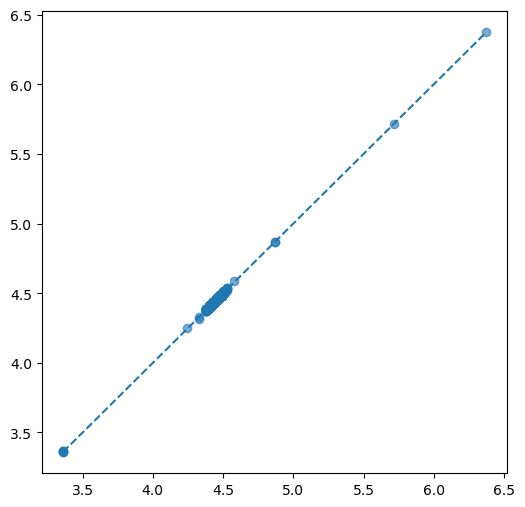

In [16]:
# 선형회귀 결과 시각화
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred_linear, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], linestyle="--")
plt.show()

In [17]:
# 선형회귀 계수 확인
coef_df = pd.DataFrame({
    "feature": X.columns,
    "coefficient": linear_model.coef_
}).sort_values("coefficient", ascending=False)

print("\n=== 선형회귀 계수 ===")
display(coef_df)


=== 선형회귀 계수 ===


,feature,coefficient
0,Injection_Time,0.986438
3,Clamp_Close_Time,0.024235
4,Cushion_Position,0.005317
6,Clamp_Open_Position,0.005232
10,Max_Injection_Pressure,0.003188
1,Plasticizing_Time,0.002584
19,Barrel_Temperature_6,0.000857
22,Mold_Temperature_4,0.000836
13,Average_Back_Pressure,0.000514
8,Max_Screw_RPM,0.000469


In [18]:
# 기준 모델 2: Ridge
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train, y_train)
y_pred_ridge = ridge_model.predict(X_test)
reg_metrics(y_test, y_pred_ridge, ridge_model, "Ridge Regression")

{'mae': 0.005043817143220453,
 'rmse': 0.007213161931926641,
 'r2': 0.9947597886577637,
 'model': Ridge(),
 'model_name': 'Ridge Regression'}

In [19]:
# Ridge 회귀 계수 확인
ridge_coef_df = pd.DataFrame({
    "feature": X.columns,
    "coefficient": ridge_model.coef_
}).sort_values("coefficient", ascending=False)

print("\n=== Ridge 회귀 계수 (alpha=1.0) ===")
display(ridge_coef_df)

# 참고: 절편(Intercept) 확인
print(f"Ridge 모델 절편: {ridge_model.intercept_:.4f}")


=== Ridge 회귀 계수 (alpha=1.0) ===


,feature,coefficient
0,Injection_Time,0.841803
1,Plasticizing_Time,0.040934
3,Clamp_Close_Time,0.033913
10,Max_Injection_Pressure,0.020412
13,Average_Back_Pressure,0.014945
8,Max_Screw_RPM,0.005979
6,Clamp_Open_Position,0.005067
4,Cushion_Position,0.004825
22,Mold_Temperature_4,0.003676
11,Max_Switch_Over_Pressure,0.003272


Ridge 모델 절편: -11.3735


In [20]:
# 두 모델의 계수 비교 데이터프레임
comparison_df = pd.DataFrame({
    "feature": X.columns,
    "Linear": linear_model.coef_,
    "Ridge": ridge_model.coef_
}).set_index("feature")

print("\n=== 모델별 계수 비교 ===")
display(comparison_df.T) # 행우측 전환해서 보기 편하게 출력


=== 모델별 계수 비교 ===


feature,Injection_Time,Plasticizing_Time,Cycle_Time,Clamp_Close_Time,Cushion_Position,Plasticizing_Position,Clamp_Open_Position,Max_Injection_Speed,Max_Screw_RPM,Average_Screw_RPM,Max_Injection_Pressure,Max_Switch_Over_Pressure,Max_Back_Pressure,Average_Back_Pressure,Barrel_Temperature_1,Barrel_Temperature_2,Barrel_Temperature_3,Barrel_Temperature_4,Barrel_Temperature_5,Barrel_Temperature_6,Hopper_Temperature,Mold_Temperature_3,Mold_Temperature_4
Linear,0.986438,0.002584,0.000336,0.024235,0.005317,-0.003138,0.005232,-0.001654,0.000469,0.000006,0.003188,-0.000419,-0.000657,0.000514,0.000415,-0.000363,0.000270,-0.000050,0.000157,0.000857,0.00041,-0.001016,0.000836
Ridge,0.841803,0.040934,0.001182,0.033913,0.004825,-0.039956,0.005067,-0.022679,0.005979,0.000049,0.020412,0.003272,-0.015670,0.014945,0.000210,-0.000948,0.000704,0.001229,0.000925,-0.000811,0.00195,-0.004128,0.003676


In [21]:
# 비교 모델 3: Decision Tree Regressor
tree_model = DecisionTreeRegressor(random_state=42)
tree_model.fit(X_train, y_train)
y_pred_tree = tree_model.predict(X_test)
reg_metrics(y_test, y_pred_tree, tree_model, "Decision Tree Regressor")

{'mae': 0.0002225527789328597,
 'rmse': 0.0014918231436901288,
 'r2': 0.9997758534185892,
 'model': DecisionTreeRegressor(random_state=42),
 'model_name': 'Decision Tree Regressor'}

In [22]:
# Decision Tree 특성 중요도 확인
tree_importance_df = pd.DataFrame({
    "feature": X.columns,
    "importance": tree_model.feature_importances_
}).sort_values("importance", ascending=False)

print("\n=== Decision Tree 특성 중요도 ===")
display(tree_importance_df)


=== Decision Tree 특성 중요도 ===


,feature,importance
7,Max_Injection_Speed,0.538361
20,Hopper_Temperature,0.308145
0,Injection_Time,0.061443
3,Clamp_Close_Time,0.051947
2,Cycle_Time,0.038745
10,Max_Injection_Pressure,0.000379
1,Plasticizing_Time,0.000114
13,Average_Back_Pressure,0.000088
16,Barrel_Temperature_3,0.000087
15,Barrel_Temperature_2,0.000076


In [23]:
%%time
# 비교 모델 4: Random Forest Regressor
rf_model = RandomForestRegressor(
    n_estimators=300,
    random_state=42
)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

reg_metrics(y_test, y_pred_rf, rf_model, "Random Forest Regressor")
# Wall time: 5.79 s

CPU times: user 5.98 s, sys: 150 ms, total: 6.13 s
Wall time: 5.85 s


{'mae': 0.0009646381749524339,
 'rmse': 0.00272582745250591,
 'r2': 0.9992516682684299,
 'model': RandomForestRegressor(n_estimators=300, random_state=42),
 'model_name': 'Random Forest Regressor'}

In [24]:
# 1. 평가 결과를 담을 리스트 생성
results = []

# 2. 모델별로 함수 호출 후 리스트에 추가
results.append(reg_metrics(y_test, y_pred_linear, linear_model, "Linear Regression"))
results.append(reg_metrics(y_test, y_pred_ridge, ridge_model, "Ridge Regression"))
results.append(reg_metrics(y_test, y_pred_tree, tree_model, "Decision Tree"))
results.append(reg_metrics(y_test, y_pred_rf, rf_model, "Random Forest"))

# 3. 데이터프레임 생성 및 정렬
compare_df = pd.DataFrame(results).sort_values("rmse")

print("\n=== 회귀 모델 비교표 ===")
display(compare_df)


=== 회귀 모델 비교표 ===


,mae,rmse,r2,model,model_name
2,0.000223,0.001492,0.999776,DecisionTreeRegressor(random_state=42),Decision Tree
3,0.000965,0.002726,0.999252,"(DecisionTreeRegressor(max_features=1.0, rando...",Random Forest
0,0.004842,0.004930,0.997553,LinearRegression(),Linear Regression
1,0.005044,0.007213,0.994760,Ridge(),Ridge Regression


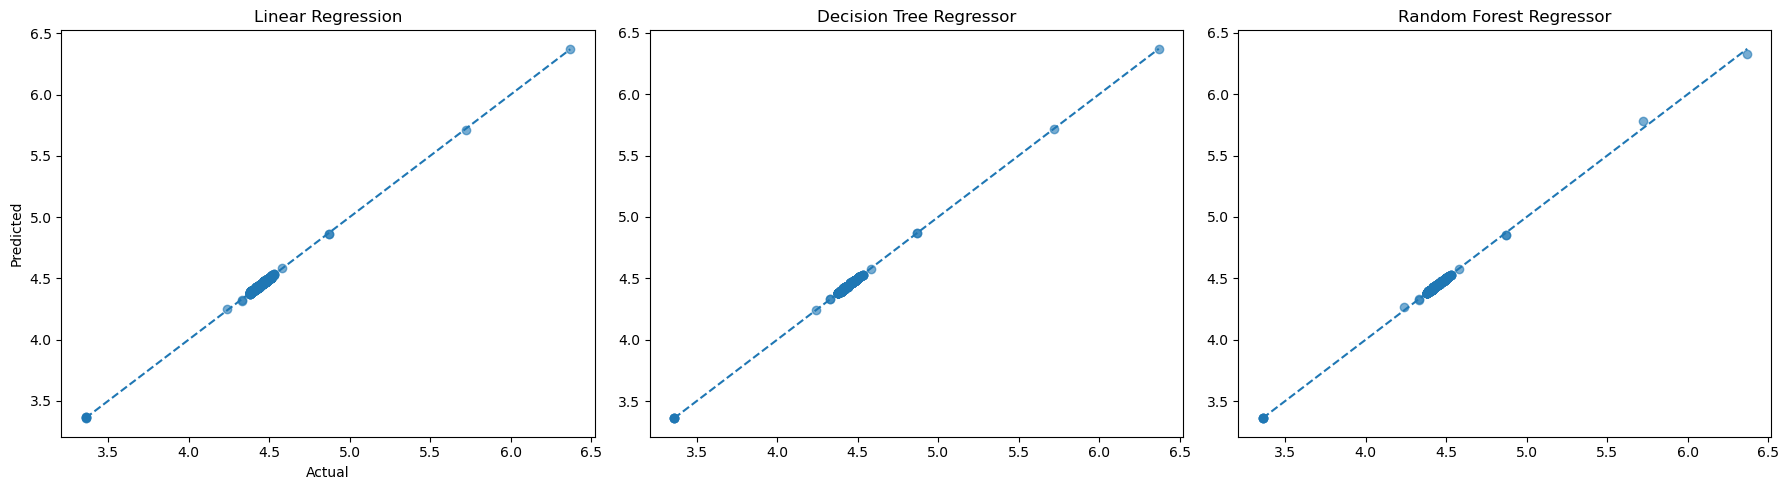

In [25]:
# 여러 모델 Actual vs Predicted 비교 시각화
plt.figure(figsize=(18, 5))
plt.subplot(131)
plt.scatter(y_test, y_pred_linear, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], linestyle="--")
plt.title("Linear Regression")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.subplot(132)
plt.scatter(y_test, y_pred_tree, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], linestyle="--")
plt.title("Decision Tree Regressor")
plt.subplot(133)
plt.scatter(y_test, y_pred_rf, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], linestyle="--")
plt.title("Random Forest Regressor")
plt.tight_layout()
plt.show()

In [26]:
# 잔차(residual) 분석
residual_df = pd.DataFrame({
    "actual": y_test.values,
    "pred_linear": y_pred_linear,
    "pred_rf": y_pred_rf
}, index=y_test.index)

residual_df["residual_linear"] = residual_df["actual"] - residual_df["pred_linear"]
residual_df["residual_rf"] = residual_df["actual"] - residual_df["pred_rf"]

print("\n=== 잔차 데이터 일부 ===")
display(residual_df.head())


=== 잔차 데이터 일부 ===


,actual,pred_linear,pred_rf,residual_linear,residual_rf
381,4.42,4.425144,4.421167,-0.005144,-1.166638e-03
2877,4.39,4.384286,4.390000,0.005713,4.440892e-15
5314,4.47,4.474351,4.470000,-0.004351,2.042810e-14
2018,4.48,4.484766,4.480467,-0.004766,-4.666551e-04
2185,4.51,4.504891,4.509134,0.005110,8.666865e-04


In [27]:
# Random Forest 중요 변수 확인
rf_importance_df = pd.DataFrame({
    "feature": X.columns,
    "importance": rf_model.feature_importances_
}).sort_values("importance", ascending=False)

print("\n=== Random Forest 중요 변수 ===")
display(rf_importance_df)


=== Random Forest 중요 변수 ===


,feature,importance
7,Max_Injection_Speed,0.337873
0,Injection_Time,0.169396
11,Max_Switch_Over_Pressure,0.153688
10,Max_Injection_Pressure,0.031026
19,Barrel_Temperature_6,0.029677
4,Cushion_Position,0.028857
17,Barrel_Temperature_4,0.025870
12,Max_Back_Pressure,0.023397
13,Average_Back_Pressure,0.022012
14,Barrel_Temperature_1,0.021876


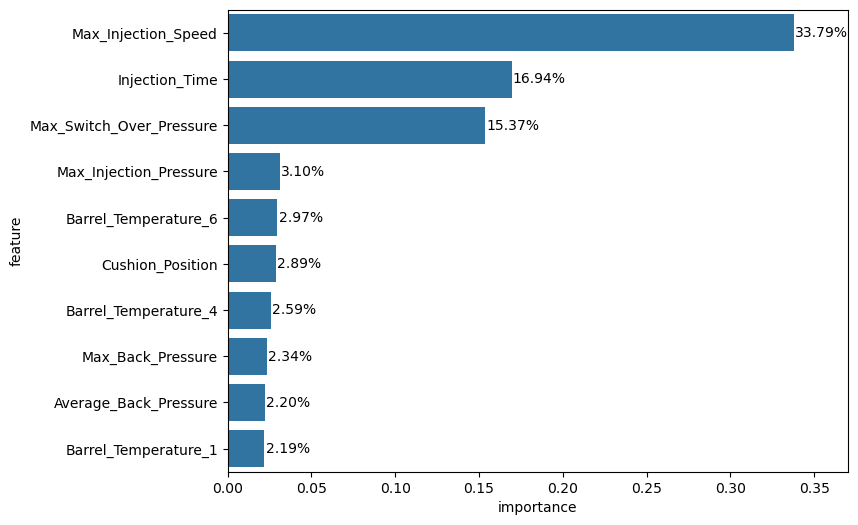

In [28]:
plt.figure(figsize=(8, 6))
ax = sns.barplot(data=rf_importance_df.head(10), x="importance", y="feature")
for i in ax.containers:
    ax.bar_label(i, fmt="{:.2%}", padding=1)
plt.xlim(0, 0.37)
plt.show()

In [29]:
%%time
# Wall time: 32 s
# 하이퍼파라미터 튜닝 - Random Forest
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 3, 5, 10],
    "min_samples_split": [2, 5]
}

grid = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    scoring="neg_root_mean_squared_error",
    cv=3,
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("\n=== GridSearchCV 결과 ===")
print("Best Params:", grid.best_params_)
print("Best CV Score (negative RMSE):", grid.best_score_)

best_rf = grid.best_estimator_
y_pred_best_rf = best_rf.predict(X_test)

reg_metrics(y_test, y_pred_best_rf, "Tuned Random Forest Regressor")


=== GridSearchCV 결과 ===
Best Params: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 300}
Best CV Score (negative RMSE): -0.02058975121335132
CPU times: user 6.04 s, sys: 181 ms, total: 6.23 s
Wall time: 32 s


{'mae': 0.0009646381749524339,
 'rmse': 0.00272582745250591,
 'r2': 0.9992516682684299,
 'model': 'Tuned Random Forest Regressor',
 'model_name': 'Model'}

In [30]:
# 튜닝 전후 비교
tuned_results = [
    reg_metrics(y_test, y_pred_rf, rf_model, "Random Forest"),
    reg_metrics(y_test, y_pred_best_rf, best_rf, "Tuned Random Forest")
]
tuned_compare_df = pd.DataFrame(tuned_results)
print("\n=== 튜닝 전후 비교 ===")
display(tuned_compare_df[['model_name', 'mae', 'rmse', 'r2']])


=== 튜닝 전후 비교 ===


,model_name,mae,rmse,r2
0,Random Forest,0.000965,0.002726,0.999252
1,Tuned Random Forest,0.000965,0.002726,0.999252


In [31]:
# 샘플 1건 예측
sample_input = X_test.iloc[[0]].copy()

print("\n=== 샘플 입력 데이터 ===")
display(sample_input)

sample_pred_linear = linear_model.predict(sample_input)[0]
sample_pred_rf = rf_model.predict(sample_input)[0]
sample_pred_best_rf = best_rf.predict(sample_input)[0]
sample_actual = y_test.loc[sample_input.index].values[0]

print("\n=== 샘플 1건 예측 결과 ===")
print("실제값:", round(sample_actual, 4))
print("Linear Regression 예측값:", round(sample_pred_linear, 4))
print("Random Forest 예측값:", round(sample_pred_rf, 4))
print("Tuned Random Forest 예측값:", round(sample_pred_best_rf, 4))


=== 샘플 입력 데이터 ===


,Injection_Time,Plasticizing_Time,Cycle_Time,Clamp_Close_Time,Cushion_Position,Plasticizing_Position,Clamp_Open_Position,Max_Injection_Speed,Max_Screw_RPM,Average_Screw_RPM,Max_Injection_Pressure,Max_Switch_Over_Pressure,Max_Back_Pressure,Average_Back_Pressure,Barrel_Temperature_1,Barrel_Temperature_2,Barrel_Temperature_3,Barrel_Temperature_4,Barrel_Temperature_5,Barrel_Temperature_6,Hopper_Temperature,Mold_Temperature_3,Mold_Temperature_4
381,9.54,17.059999,59.52,7.13,653.409973,68.480003,647.98999,56.200001,30.9,292.5,141.899994,136.399994,38.400002,59.599998,276.200012,274.899994,275.0,271.100006,255.100006,230.199997,67.199997,22.700001,23.799999



=== 샘플 1건 예측 결과 ===
실제값: 4.42
Linear Regression 예측값: 4.4251
Random Forest 예측값: 4.4212
Tuned Random Forest 예측값: 4.4212


In [32]:
# end